### Nassau Candy Distributor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

Matplotlib is building the font cache; this may take a moment.


In [2]:
sns.set_theme(style="whitegrid")
df = pd.read_csv("Nassau Candy Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)

Shape: (10194, 18)

Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

Data types:
 Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object


In [4]:
df[['Sales', 'Units', 'Cost', 'Gross Profit']].describe()

,Sales,Units,Cost,Gross Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.908537,3.791838,4.742087,9.166451
std,11.341020,2.228317,5.061647,6.643740
min,1.250000,1.000000,0.600000,0.250000
25%,7.200000,2.000000,2.400000,4.900000
50%,10.800000,3.000000,3.600000,7.470000
75%,18.000000,5.000000,5.700000,12.250000
max,260.000000,14.000000,130.000000,130.000000


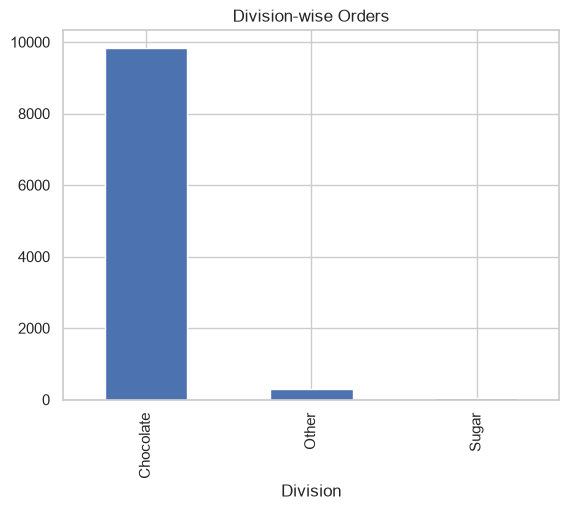

In [5]:
df['Division'].value_counts().plot(kind='bar', title='Division-wise Orders')
plt.show()

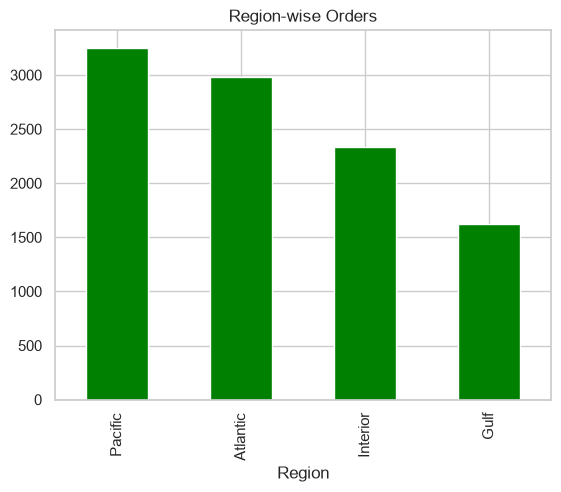

In [6]:
df['Region'].value_counts().plot(kind='bar', title='Region-wise Orders', color='green')
plt.show()

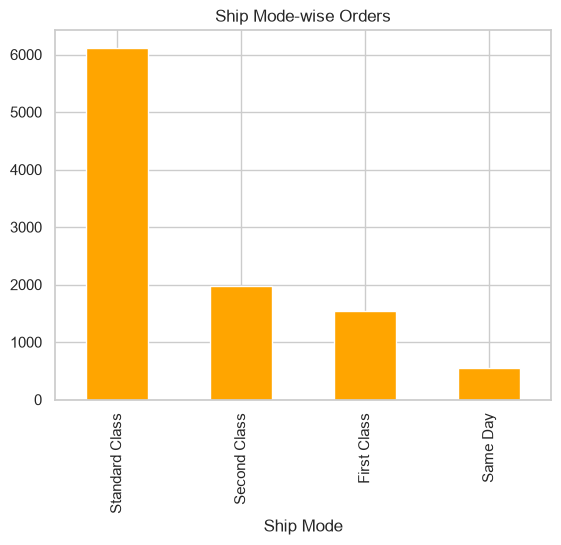

In [7]:
df['Ship Mode'].value_counts().plot(kind='bar', title='Ship Mode-wise Orders', color='orange')
plt.show()

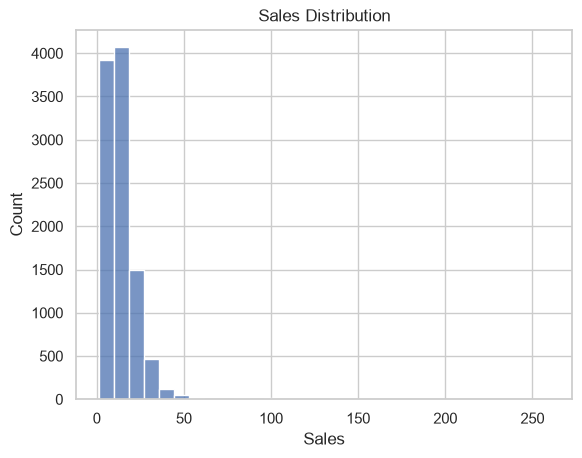

In [8]:
sns.histplot(df['Sales'], bins=30)
plt.title('Sales Distribution')
plt.show()

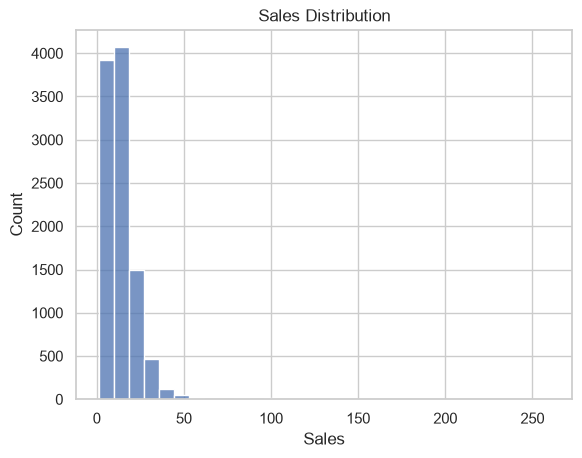

In [9]:
sns.histplot(df['Sales'], bins=30)
plt.title('Sales Distribution')
plt.show()

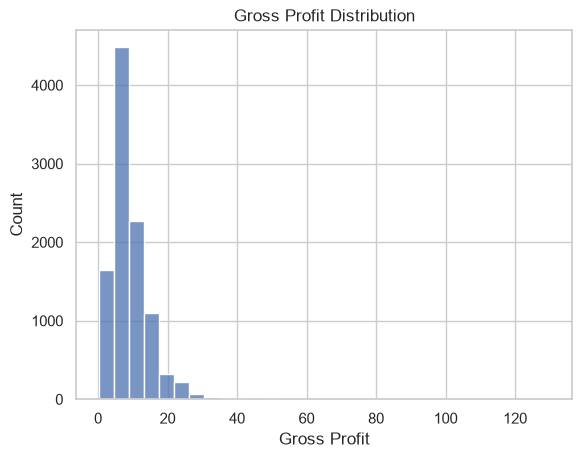

In [10]:
sns.histplot(df['Gross Profit'], bins=30)
plt.title('Gross Profit Distribution')
plt.show()

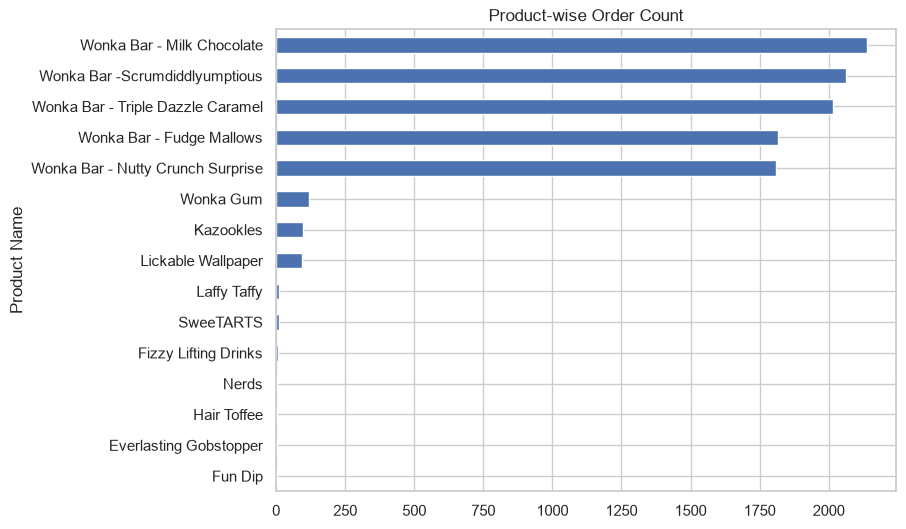

In [11]:
df['Product Name'].value_counts().plot(kind='barh', figsize=(8,6))
plt.gca().invert_yaxis()
plt.title('Product-wise Order Count')
plt.show()

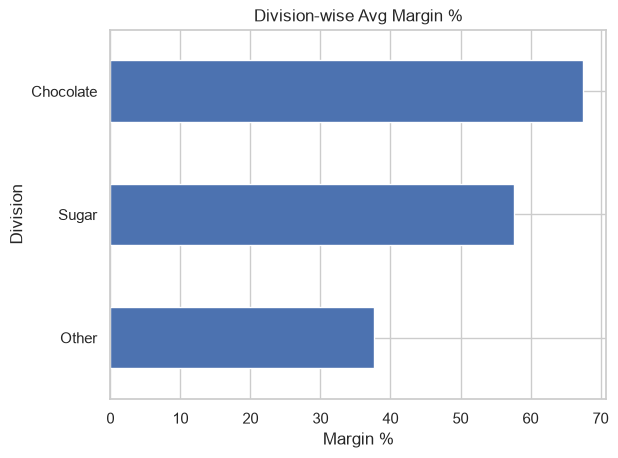

In [12]:
df['Margin_Pct'] = df['Gross Profit'] / df['Sales'] * 100
df.groupby('Division')['Margin_Pct'].mean().sort_values().plot(kind='barh', title='Division-wise Avg Margin %')
plt.xlabel('Margin %')
plt.show()

#### Now let's look at the Problem — Lead Time

In [13]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')
df['Lead_Time_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df['Lead_Time_Days'].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead_Time_Days, dtype: float64

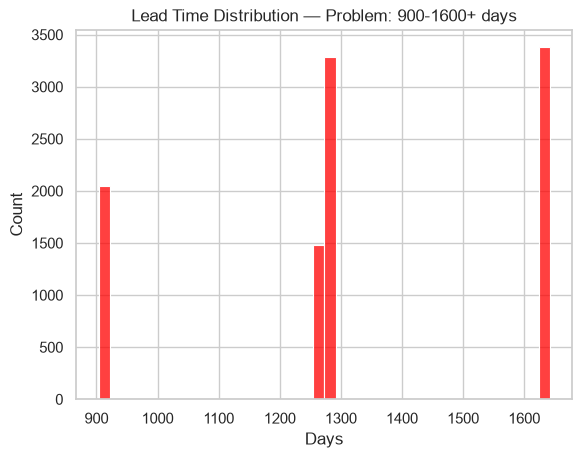

In [14]:
sns.histplot(df['Lead_Time_Days'], bins=40, color='red')
plt.title('Lead Time Distribution — Problem: 900-1600+ days')
plt.xlabel('Days')
plt.show()

In [15]:
Q1 = df['Lead_Time_Days'].quantile(0.25)
Q3 = df['Lead_Time_Days'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

cleaned = df[(df['Lead_Time_Days'] >= lower) & (df['Lead_Time_Days'] <= upper)]
print("Rows before:", len(df))
print("Rows after outlier removal:", len(cleaned))

Rows before: 10194
Rows after outlier removal: 10194


In [16]:
FACTORY_COORDS = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.119140, -96.181150),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.117500, -89.971107),
}

PRODUCT_FACTORY_MAP = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory",
}

REGION_COORDS = {
    "Interior": (39.8283, -98.5795),
    "Atlantic": (38.9072, -77.0369),
    "Gulf": (29.7604, -95.3698),
    "Pacific": (37.7749, -122.4194),
}

In [17]:
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

In [18]:
df['Current Factory'] = df['Product Name'].map(PRODUCT_FACTORY_MAP)

df['_cust_lat'] = df['Region'].map(lambda r: REGION_COORDS[r][0])
df['_cust_lon'] = df['Region'].map(lambda r: REGION_COORDS[r][1])
df['_fac_lat'] = df['Current Factory'].map(lambda f: FACTORY_COORDS[f][0])
df['_fac_lon'] = df['Current Factory'].map(lambda f: FACTORY_COORDS[f][1])

df['Distance_Miles'] = haversine_miles(df['_cust_lat'], df['_cust_lon'], df['_fac_lat'], df['_fac_lon'])

df[['Product Name', 'Current Factory', 'Distance_Miles']].head(10)

,Product Name,Current Factory,Distance_Miles
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,1112.497816
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,1112.497816
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,875.425373
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,875.425373
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,523.978594
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,990.517611
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,860.844477
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,860.844477
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,990.517611
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,860.844477


In [19]:
SHIP_MODE_BASE = {"Same Day": 0.3, "First Class": 1.0, "Second Class": 2.0, "Standard Class": 3.0}
SHIP_MODE_RATE = {"Same Day": 0.15, "First Class": 0.45, "Second Class": 0.75, "Standard Class": 1.30}

rng = np.random.default_rng(42)
base = df['Ship Mode'].map(SHIP_MODE_BASE)
rate = df['Ship Mode'].map(SHIP_MODE_RATE)
noise = rng.normal(0, 0.4, size=len(df))

df['Lead_Time_Fixed'] = (base + (df['Distance_Miles']/1000)*rate + noise).clip(lower=0.5).round(2)

df['Lead_Time_Fixed'].describe()

count    10194.000000
mean         3.573334
std          1.549473
min          0.500000
25%          2.450000
50%          3.760000
75%          4.510000
max          7.300000
Name: Lead_Time_Fixed, dtype: float64

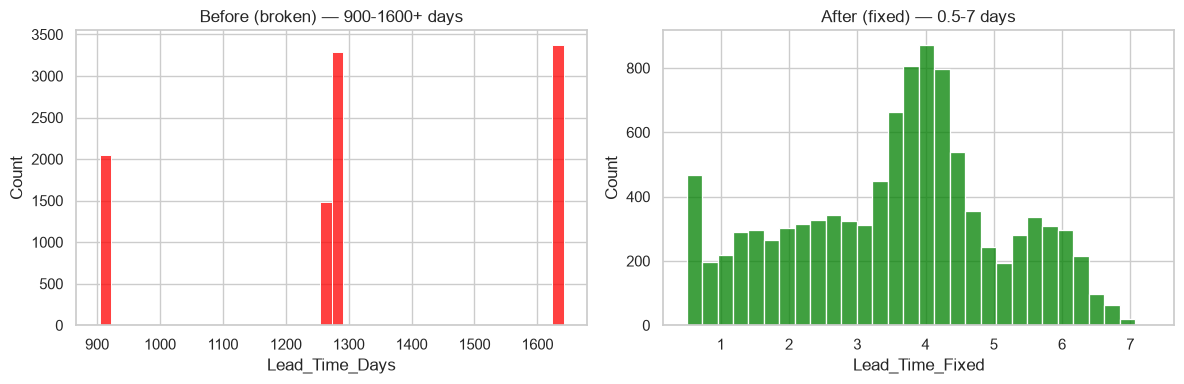

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['Lead_Time_Days'], bins=40, ax=axes[0], color='red')
axes[0].set_title('Before (broken) — 900-1600+ days')

sns.histplot(df['Lead_Time_Fixed'], bins=30, ax=axes[1], color='green')
axes[1].set_title('After (fixed) — 0.5-7 days')

plt.tight_layout()
plt.show()

#### Model Training

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [22]:
categorical_features = ['Current Factory', 'Region', 'Ship Mode', 'Division', 'Product Name']
numeric_features = ['Distance_Miles', 'Sales', 'Units', 'Cost']
target = 'Lead_Time_Fixed'

X = df[categorical_features + numeric_features]
y = df[target]

X.head()

,Current Factory,Region,Ship Mode,Division,Product Name,Distance_Miles,Sales,Units,Cost
0,Wicked Choccy's,Interior,Standard Class,Chocolate,Wonka Bar - Milk Chocolate,1112.497816,6.50,2,2.28
1,Wicked Choccy's,Interior,Standard Class,Chocolate,Wonka Bar - Triple Dazzle Caramel,1112.497816,7.50,2,2.60
2,Lot's O' Nuts,Interior,Standard Class,Chocolate,Wonka Bar - Nutty Crunch Surprise,875.425373,10.47,3,3.00
3,Lot's O' Nuts,Interior,Standard Class,Chocolate,Wonka Bar -Scrumdiddlyumptious,875.425373,10.80,3,3.30
4,Wicked Choccy's,Atlantic,Standard Class,Chocolate,Wonka Bar - Triple Dazzle Caramel,523.978594,11.25,3,3.90


In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 8155
Testing rows: 2039


### Build the preprocessing pipeline

In [24]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ('num', StandardScaler(), numeric_features)
])

In [25]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.08, random_state=42)
}

In [26]:
results = {}
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2}
    fitted_models[name] = pipe

    print(f"{name:20s}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}")

Linear Regression     RMSE=0.4781  MAE=0.3801  R2=0.9054


Random Forest         RMSE=0.4090  MAE=0.3223  R2=0.9308


Gradient Boosting     RMSE=0.3970  MAE=0.3136  R2=0.9348


In [27]:
results_df = pd.DataFrame(results).T
results_df

,RMSE,MAE,R2
Linear Regression,0.478131,0.380105,0.905433
Random Forest,0.408958,0.322267,0.930817
Gradient Boosting,0.397036,0.313639,0.934792


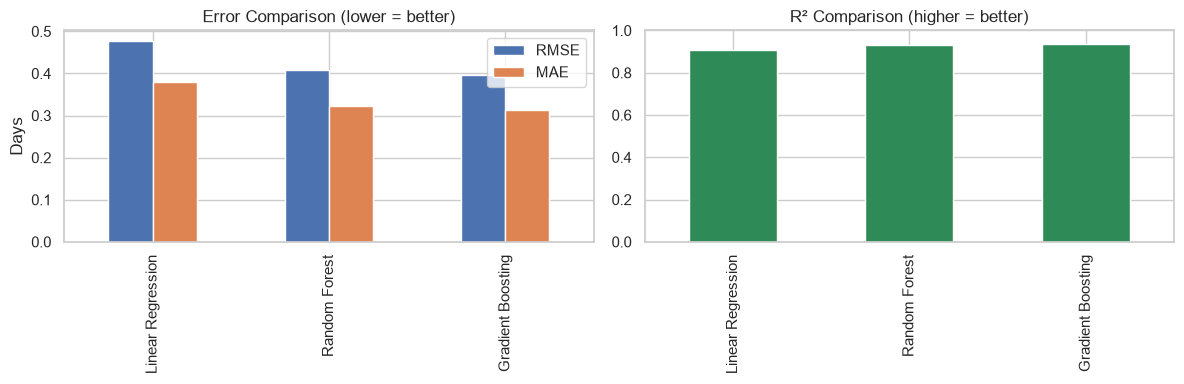

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
results_df[['RMSE','MAE']].plot(kind='bar', ax=axes[0], title='Error Comparison (lower = better)')
axes[0].set_ylabel('Days')

results_df['R2'].plot(kind='bar', ax=axes[1], color='seagreen', title='R² Comparison (higher = better)')
axes[1].set_ylim(0,1)

plt.tight_layout()
plt.show()

In [29]:
best_name = results_df['RMSE'].idxmin()
best_pipeline = fitted_models[best_name]

print("Best model:", best_name)
print(results_df.loc[best_name])

Best model: Gradient Boosting
RMSE    0.397036
MAE     0.313639
R2      0.934792
Name: Gradient Boosting, dtype: float64


In [30]:
import joblib

joblib.dump({
    "pipeline": best_pipeline,
    "name": best_name,
    "metrics": results[best_name],
    "categorical_features": categorical_features,
    "numeric_features": numeric_features
}, "best_model.pkl")

print("Model saved as best_model.pkl")

Model saved as best_model.pkl


### Clustering

In [31]:
from sklearn.cluster import KMeans

In [32]:
route_summary = df.groupby(['Current Factory', 'Region', 'Product Name'], as_index=False).agg(
    avg_lead_time=('Lead_Time_Fixed', 'mean'),
    avg_distance=('Distance_Miles', 'mean'),
    avg_margin_pct=('Margin_Pct', 'mean'),
    total_units=('Units', 'sum'),
    order_count=('Row ID', 'count')
)

route_summary.head(10)

,Current Factory,Region,Product Name,avg_lead_time,avg_distance,avg_margin_pct,total_units,order_count
0,Lot's O' Nuts,Atlantic,Wonka Bar - Fudge Mallows,4.290182,1975.575771,66.666667,2008,548
1,Lot's O' Nuts,Atlantic,Wonka Bar - Nutty Crunch Surprise,4.244082,1975.575771,71.346705,1857,490
2,Lot's O' Nuts,Atlantic,Wonka Bar -Scrumdiddlyumptious,4.243933,1975.575771,69.444444,2349,623
3,Lot's O' Nuts,Gulf,Wonka Bar - Fudge Mallows,3.316323,990.517611,66.666667,1082,291
4,Lot's O' Nuts,Gulf,Wonka Bar - Nutty Crunch Surprise,3.341689,990.517611,71.346705,1088,296
5,Lot's O' Nuts,Gulf,Wonka Bar -Scrumdiddlyumptious,3.411548,990.517611,69.444444,1203,310
6,Lot's O' Nuts,Interior,Wonka Bar - Fudge Mallows,3.268585,875.425373,66.666667,1595,410
7,Lot's O' Nuts,Interior,Wonka Bar - Nutty Crunch Surprise,3.268894,875.425373,71.346705,1694,452
8,Lot's O' Nuts,Interior,Wonka Bar -Scrumdiddlyumptious,3.397603,875.425373,69.444444,1723,459
9,Lot's O' Nuts,Pacific,Wonka Bar - Fudge Mallows,3.083374,688.408629,66.666667,2229,569


In [33]:
features_for_clustering = route_summary[['avg_lead_time', 'avg_distance', 'avg_margin_pct']]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(features_for_clustering)

In [34]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
route_summary['cluster'] = kmeans.fit_predict(X_cluster)

route_summary.head(10)

,Current Factory,Region,Product Name,avg_lead_time,avg_distance,avg_margin_pct,total_units,order_count,cluster
0,Lot's O' Nuts,Atlantic,Wonka Bar - Fudge Mallows,4.290182,1975.575771,66.666667,2008,548,1
1,Lot's O' Nuts,Atlantic,Wonka Bar - Nutty Crunch Surprise,4.244082,1975.575771,71.346705,1857,490,1
2,Lot's O' Nuts,Atlantic,Wonka Bar -Scrumdiddlyumptious,4.243933,1975.575771,69.444444,2349,623,1
3,Lot's O' Nuts,Gulf,Wonka Bar - Fudge Mallows,3.316323,990.517611,66.666667,1082,291,2
4,Lot's O' Nuts,Gulf,Wonka Bar - Nutty Crunch Surprise,3.341689,990.517611,71.346705,1088,296,2
5,Lot's O' Nuts,Gulf,Wonka Bar -Scrumdiddlyumptious,3.411548,990.517611,69.444444,1203,310,2
6,Lot's O' Nuts,Interior,Wonka Bar - Fudge Mallows,3.268585,875.425373,66.666667,1595,410,2
7,Lot's O' Nuts,Interior,Wonka Bar - Nutty Crunch Surprise,3.268894,875.425373,71.346705,1694,452,2
8,Lot's O' Nuts,Interior,Wonka Bar -Scrumdiddlyumptious,3.397603,875.425373,69.444444,1723,459,2
9,Lot's O' Nuts,Pacific,Wonka Bar - Fudge Mallows,3.083374,688.408629,66.666667,2229,569,2


In [35]:
cluster_means = route_summary.groupby('cluster')['avg_lead_time'].mean().sort_values()
rank_map = {cluster_id: rank for rank, cluster_id in enumerate(cluster_means.index)}

labels = ['Fast & Reliable', 'Moderate', 'Slow', 'Congested / High-Risk']
route_summary['cluster_label'] = route_summary['cluster'].map(rank_map).map({i: labels[i] for i in range(4)})

route_summary['cluster_label'].value_counts()

cluster_label
Slow                     21
Congested / High-Risk    15
Fast & Reliable          13
Moderate                  4
Name: count, dtype: int64

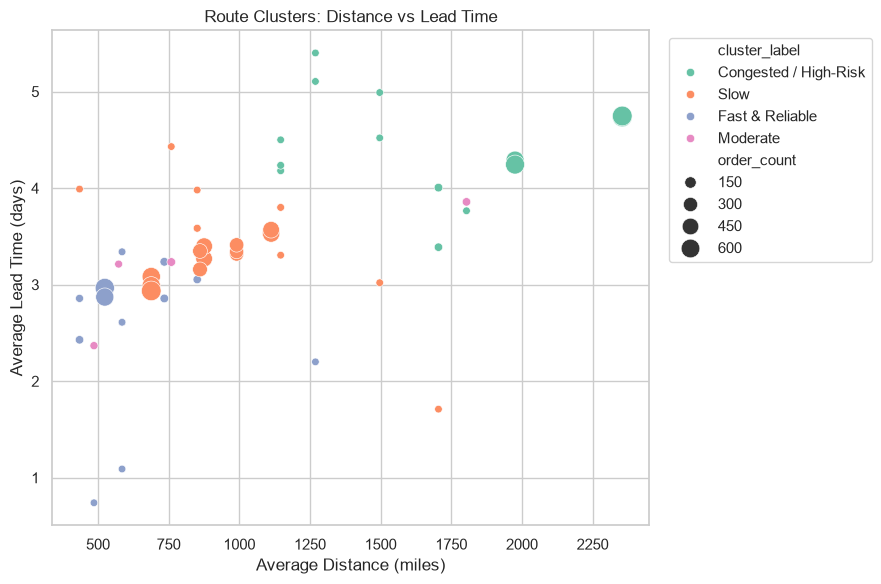

In [36]:
plt.figure(figsize=(9,6))
sns.scatterplot(data=route_summary, x='avg_distance', y='avg_lead_time',
                 hue='cluster_label', size='order_count', sizes=(30,200), palette='Set2')
plt.title('Route Clusters: Distance vs Lead Time')
plt.xlabel('Average Distance (miles)')
plt.ylabel('Average Lead Time (days)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
route_summary.sort_values('avg_lead_time', ascending=False).head(10)

,Current Factory,Region,Product Name,avg_lead_time,avg_distance,avg_margin_pct,total_units,order_count,cluster,cluster_label
28,Sugar Shack,Gulf,Fizzy Lifting Drinks,5.400000,1269.210634,60.000000,4,1,1,Congested / High-Risk
30,Sugar Shack,Gulf,Laffy Taffy,5.105000,1269.210634,62.311558,11,2,1,Congested / High-Risk
35,Sugar Shack,Pacific,Fizzy Lifting Drinks,4.990000,1496.722950,60.000000,3,1,1,Congested / High-Risk
52,Wicked Choccy's,Pacific,Wonka Bar - Triple Dazzle Caramel,4.747352,2354.945077,65.333333,2595,676,1,Congested / High-Risk
51,Wicked Choccy's,Pacific,Wonka Bar - Milk Chocolate,4.736201,2354.945077,64.923077,2706,666,1,Congested / High-Risk
36,Sugar Shack,Pacific,Laffy Taffy,4.520000,1496.722950,62.311558,1,1,1,Congested / High-Risk
24,Sugar Shack,Atlantic,Fun Dip,4.500000,1146.262822,40.000000,4,1,1,Congested / High-Risk
38,The Other Factory,Atlantic,Hair Toffee,4.430000,759.282051,77.777778,5,1,2,Slow
0,Lot's O' Nuts,Atlantic,Wonka Bar - Fudge Mallows,4.290182,1975.575771,66.666667,2008,548,1,Congested / High-Risk
1,Lot's O' Nuts,Atlantic,Wonka Bar - Nutty Crunch Surprise,4.244082,1975.575771,71.346705,1857,490,1,Congested / High-Risk


In [38]:
route_summary.to_csv('route_clusters.csv', index=False)
print("Saved route_clusters.csv")

Saved route_clusters.csv


### Simulation function

In [39]:
def simulate_product(product, df_hist, pipeline):
    # Get historical averages for this product
    prod_hist = df_hist[df_hist['Product Name'] == product]
    if prod_hist.empty:
        prod_hist = df_hist

    avg_sales = prod_hist['Sales'].mean()
    avg_units = prod_hist['Units'].mean()
    avg_cost = prod_hist['Cost'].mean()
    division = prod_hist['Division'].mode().iloc[0]
    ship_mode = prod_hist['Ship Mode'].mode().iloc[0]

    # Build one row for every possible factory x region combination
    rows = []
    for factory, (flat, flon) in FACTORY_COORDS.items():
        for region, (rlat, rlon) in REGION_COORDS.items():
            dist = haversine_miles(rlat, rlon, flat, flon)
            rows.append({
                'Current Factory': factory,
                'Region': region,
                'Ship Mode': ship_mode,
                'Division': division,
                'Product Name': product,
                'Distance_Miles': dist,
                'Sales': avg_sales,
                'Units': avg_units,
                'Cost': avg_cost
            })
    candidates = pd.DataFrame(rows)

    # Predict lead time for every candidate factory
    candidates['Predicted_Lead_Time'] = pipeline.predict(candidates[categorical_features + numeric_features])

    # Weight by how often each region actually orders this product
    weights = prod_hist['Region'].value_counts(normalize=True).to_dict()
    default_weight = 1.0 / len(REGION_COORDS)
    candidates['_weight'] = candidates['Region'].map(lambda r: weights.get(r, default_weight))

    # Average predicted lead time per factory (weighted)
    factory_scores = candidates.groupby('Current Factory').apply(
        lambda g: np.average(g['Predicted_Lead_Time'], weights=g['_weight'])
    ).rename('Expected_Lead_Time').reset_index()

    # Compare to current factory
    current_factory = PRODUCT_FACTORY_MAP.get(product)
    current_lt = factory_scores.loc[factory_scores['Current Factory'] == current_factory, 'Expected_Lead_Time']
    current_lt = float(current_lt.iloc[0]) if not current_lt.empty else np.nan

    factory_scores['Current_Assignment'] = factory_scores['Current Factory'] == current_factory
    factory_scores['Lead_Time_Reduction_Pct'] = ((current_lt - factory_scores['Expected_Lead_Time']) / current_lt) * 100

    factory_scores = factory_scores.sort_values('Expected_Lead_Time').reset_index(drop=True)
    return factory_scores

In [40]:
example_product = "Wonka Bar - Milk Chocolate"
result = simulate_product(example_product, df, best_pipeline)
result

,Current Factory,Expected_Lead_Time,Current_Assignment,Lead_Time_Reduction_Pct
0,Secret Factory,4.288714,False,8.009144
1,The Other Factory,4.341270,False,6.881833
2,Lot's O' Nuts,4.505125,False,3.367225
3,Wicked Choccy's,4.662109,True,0.000000
4,Sugar Shack,4.668001,False,-0.126388


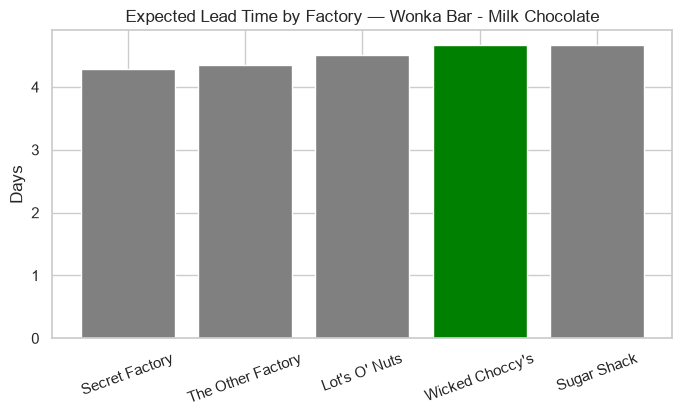

In [41]:
colors = result['Current_Assignment'].map({True: 'green', False: 'grey'})

plt.figure(figsize=(8,4))
plt.bar(result['Current Factory'], result['Expected_Lead_Time'], color=colors)
plt.title(f'Expected Lead Time by Factory — {example_product}')
plt.ylabel('Days')
plt.xticks(rotation=20)
plt.show()

In [42]:
all_recommendations = []

for product in PRODUCT_FACTORY_MAP:
    scored = simulate_product(product, df, best_pipeline)
    alternatives = scored[~scored['Current_Assignment']].head(2).copy()
    alternatives.insert(0, 'Product Name', product)
    alternatives.insert(1, 'Existing Factory', PRODUCT_FACTORY_MAP[product])
    all_recommendations.append(alternatives)

recommendations = pd.concat(all_recommendations, ignore_index=True)
recommendations = recommendations.rename(columns={'Current Factory': 'Recommended Factory'})
recommendations = recommendations[['Product Name', 'Existing Factory', 'Recommended Factory',
                                    'Expected_Lead_Time', 'Lead_Time_Reduction_Pct']]

recommendations.sort_values('Lead_Time_Reduction_Pct', ascending=False).head(15)

,Product Name,Existing Factory,Recommended Factory,Expected_Lead_Time,Lead_Time_Reduction_Pct
10,Laffy Taffy,Sugar Shack,Secret Factory,4.052789,13.777669
14,Nerds,Sugar Shack,Secret Factory,3.901271,12.824356
12,SweeTARTS,Sugar Shack,Secret Factory,3.857570,12.706272
11,Laffy Taffy,Sugar Shack,The Other Factory,4.103809,12.692237
13,SweeTARTS,Sugar Shack,The Other Factory,3.938855,10.866855
15,Nerds,Sugar Shack,The Other Factory,3.990413,10.832425
18,Fizzy Lifting Drinks,Sugar Shack,Secret Factory,4.177649,10.203302
8,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Secret Factory,4.335673,8.283314
19,Fizzy Lifting Drinks,Sugar Shack,The Other Factory,4.268654,8.247203
6,Wonka Bar - Milk Chocolate,Wicked Choccy's,Secret Factory,4.288714,8.009144


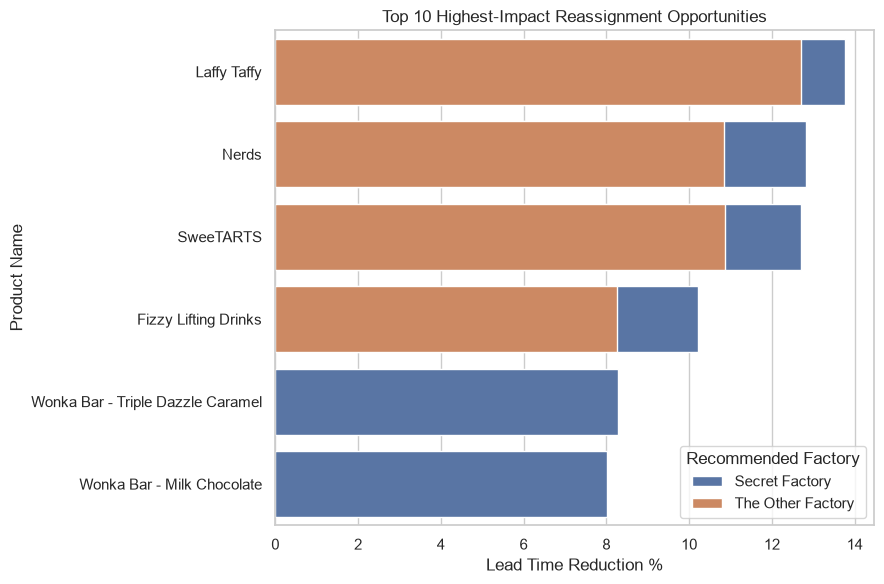

In [43]:
top10 = recommendations.sort_values('Lead_Time_Reduction_Pct', ascending=False).head(10)

plt.figure(figsize=(9,6))
sns.barplot(data=top10, y='Product Name', x='Lead_Time_Reduction_Pct', hue='Recommended Factory', dodge=False)
plt.title('Top 10 Highest-Impact Reassignment Opportunities')
plt.xlabel('Lead Time Reduction %')
plt.tight_layout()
plt.show()

In [44]:
recommendations.to_csv('recommendations.csv', index=False)
print("Saved recommendations.csv")

Saved recommendations.csv


In [45]:
df.to_csv('processed.csv', index=False)
print("Saved processed.csv")

Saved processed.csv


In [46]:
import sys
print(sys.executable)

C:\Users\vaish\Unified Mentor\.venv\Scripts\python.exe


In [48]:
import sys, sklearn
print("Python:", sys.executable)
print("scikit-learn:", sklearn.__version__)

Python: C:\Users\vaish\Unified Mentor\.venv\Scripts\python.exe
scikit-learn: 1.9.1
